this file is for us to test some of the ideas and talk

In [ ]:
!pip install transformers diffusers accelerate

first example: the example from the read me of stable-diffusion-2-base.

attention to the address of the model (here it was in my parent repository)

In [ ]:

from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler
import torch

model_id = "../stable-diffusion-2-base"

# Use the Euler scheduler here instead
scheduler = EulerDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")
pipe = StableDiffusionPipeline.from_pretrained(model_id, scheduler=scheduler, torch_dtype=torch.float32)
pipe = pipe.to("cpu")

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]  
    
image.save("astronaut_rides_horse.png")

first try, using StableDiffusionPipeline. wrote by gemimi. it isn't working, because StableDiffusionPipeline dont matter the image and mask, but only the prompt (or so i think)

this is good better, because we use StableDiffusionInpaintPipeline. this time we also not using euler like in their example, so the default scheduler is chosen. 
if i understand the task right, the scheduler is the thing that we see in the articles, so we have to implement good one. i am not sure id the thing i wrote here is the vanila or even before that, but anyway we have to write it again, more generic

In [ ]:
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# 1. טעינת ה-Pipeline הייעודי ל-Inpainting
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)
pipe.to(device)

init_image = Image.open("blue-cow.png").convert("RGB").resize((512, 512))
mask_image = Image.open("magen_david_mask.png").convert("RGB").resize((512, 512))

# 3. הגדרת הפרומפט - מה נרצה להוסיף באזור הלבן?
prompt = "a giraffe doll sitting on chair"

# 4. הרצה
# num_inference_steps: כמות הצעדים (20-50 זה סבבה)
# strength: כמה לשנות את האזור המסומן (1.0 זה שינוי מוחלט)
result_image = pipe(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=30
).images[0]

# 5. שמירה
result_image.save("real_inpainting_result.png")
print("Inpainting finished! check inpainting_result.png")

the result of the last one wasn't good. the girrafe doesn't have an head... 
if it is our vanilla we need to do it with more photos and masks and see what happens.



the next thing is the grid mask we talked about. here is the function that create simple one.
for example, if k=3, height=width=8, we will get:

10010010

00000000

00000000

10010010

00000000

00000000

10010010

00000000

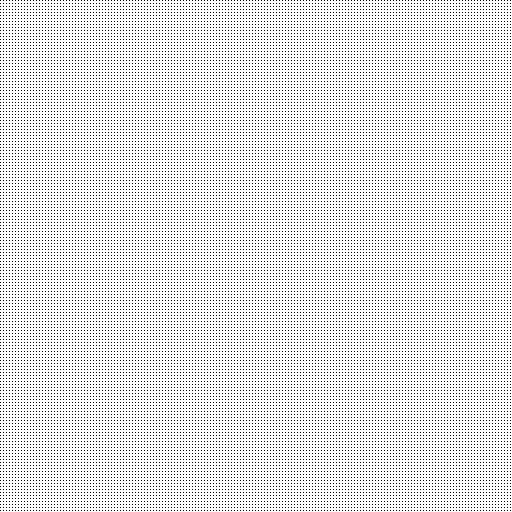

In [2]:
import numpy as np
from PIL import Image

def create_grid_mask(k, width=512, height=512):
    mask_array = np.full((height, width), 255, dtype=np.uint8)
    mask_array[::k, ::k] = 0
    return Image.fromarray(mask_array).convert("L")

create_grid_mask(3)
    

here is the test - we use the maks to repair and repaint:
repair - we use proper prompt to create the original image
repaint - we try to create another image

in this case the original image is of lemon, and the new one is for apple on the same surface

In [ ]:
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "../stable-diffusion-2-base"

# 1. טעינת ה-Pipeline הייעודי ל-Inpainting
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)
pipe.to(device)
init_image = Image.open("lemon.png").convert("RGB").resize((512, 512))
prompt_repare = "a cut lemon on a dark reflective surface"
prompt_repaint = "a cut apple on a dark reflective surface"



for k in range(2,9):
    print(k)
    mask_image = create_grid_mask(k)


    result_image = pipe(
        prompt=prompt_repare,
        image=init_image,
        mask_image=mask_image,
        num_inference_steps=30
    ).images[0]

    result_image.save(f"repair_with_k={k}.png")
    
    result_image = pipe(
        prompt=prompt_repaint,
        image=init_image,
        mask_image=mask_image,
        num_inference_steps=30
    ).images[0]

    result_image.save(f"repaint_with_k={k}.png")
    print(f"Inpainting finished! for {k} factor. check inpainting_result.png")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

2


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Inpainting finished! for 2 factor. check inpainting_result.png
3


...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Inpainting finished! for 7 factor. check inpainting_result.png
8


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

The results are very bad.
for k=2^x, we get the original imaged (i'm not sure if exactly or very very very close).

for the rest, the original data isn't helping but ruin both repaired and repainted photos

here is an exlanation:

1. The Magic Number: 8

Stable Diffusion does not look at your image pixel-by-pixel. To save memory and speed up the process, it uses a component called a VAE (Variational Autoencoder) to compress the image.

Every 8x8 block of pixels in your original image is compressed into 1 single "Latent Pixel" in the model's brain. 

If your image is $512 \times 512$, the model actually "thinks" in a grid of $64 \times 64$ ($512 \div 8 = 64$).

2. Alignment (Why 2, 4, 8 work)

When your Factor $k$ is a divisor of 8 (like 2, 4, or 8 itself), your mask patterns align perfectly with the model's internal grid.

Factor 2: Every $8 \times 8$ block in the model's brain contains exactly 16 original pixels ($4 \times 4$) in a perfect, repeating pattern.

Factor 4: Every $8 \times 8$ block contains exactly 4 original pixels ($2 \times 2$).

Factor 8: Every $8 \times 8$ block contains exactly 1 original pixel.

Because the pattern is the same in every "Latent Pixel," the model understands the structure easily. It sees a consistent "hint" of color and shape everywhere.

3. Misalignment (Why 3, 5, 6, 7 fail)

When $k$ is a number like 3, it doesn't divide 8 evenly. This creates a "staircase" effect or Aliasing.

Imagine the model's $8 \times 8$ blocks:In the first block, your mask might keep a pixel at position (0,0), (3,0), and (6,0).In the second block, the pattern shifts because 3 doesn't fit into 8. The pixels might land at (1,0), (4,0), and (7,0).The model's brain gets confused. To the AI, it looks like "jitter" or "noise" rather than a clean image. Instead of seeing a "faded lemon," it sees "random yellow dots."

so, my next try is to have k=8,16,24,32,40...

In [ ]:
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "../stable-diffusion-2-base"

# 1. טעינת ה-Pipeline הייעודי ל-Inpainting
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype
)
pipe.to(device)
init_image = Image.open("lemon.png").convert("RGB").resize((512, 512))
prompt_repare = "a cut lemon on a dark reflective surface"
prompt_repaint = "a cut apple on a dark reflective surface"



for k in range(2,9):
    print(k)
    mask_image = create_grid_mask(8*k)


    result_image = pipe(
        prompt=prompt_repare,
        image=init_image,
        mask_image=mask_image,
        num_inference_steps=30
    ).images[0]

    result_image.save(f"repair_with_k={k}.png")
    
    result_image = pipe(
        prompt=prompt_repaint,
        image=init_image,
        mask_image=mask_image,
        num_inference_steps=30
    ).images[0]

    result_image.save(f"repaint_with_k={k}.png")
    print(f"Inpainting finished! for {k} factor. check inpainting_result.png")